<a href="https://colab.research.google.com/github/enzozavaleta/EXAMENPARCIAL/blob/main/Ejercicio2_CodigoParte1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- RESULTADOS PARTE 1 ---
Lagrange 2° Grado: V(41.0)  = 0.7946 V,  |Z|(41.0) = 146.2920 Ω
Spline Cúbico:    V(41.0)  = 0.7923 V,  |Z|(41.0) = 146.2860 Ω

Lagrange 2° Grado: V(73.0)  = 0.3438 V,  |Z|(73.0) = 203.5920 Ω
Spline Cúbico:    V(73.0)  = 0.3442 V,  |Z|(73.0) = 203.5888 Ω


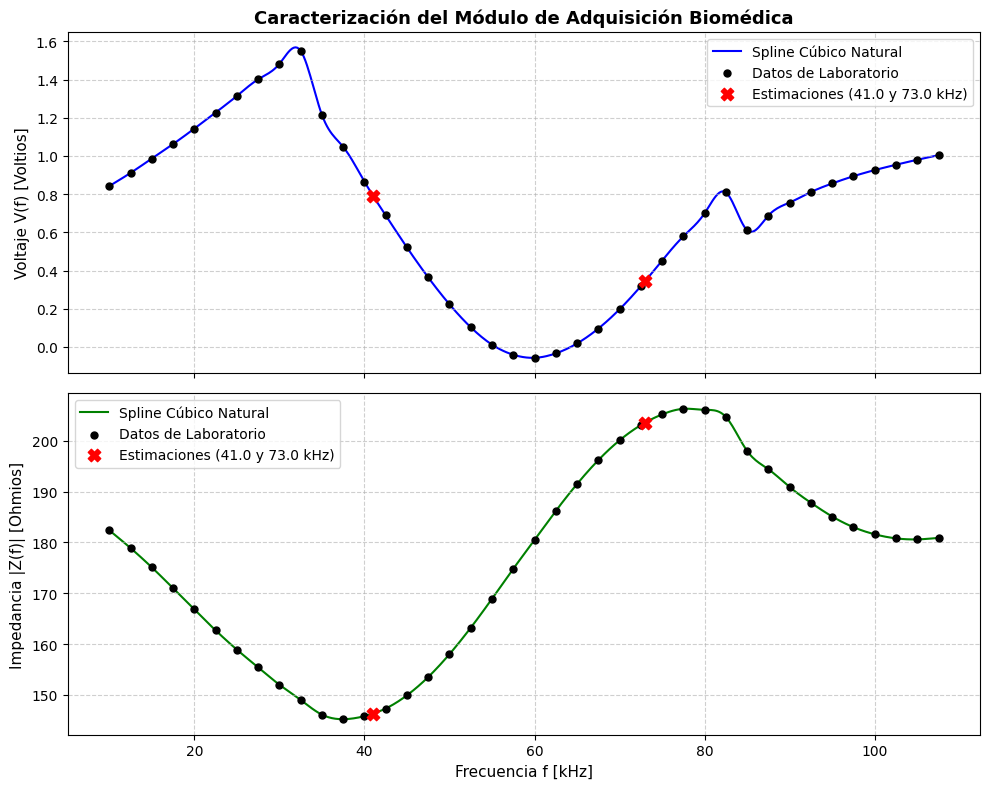

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 1. Definición de los datos del ensayo (proporcionados en el examen)
f = np.array([
    10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5, 40.0, 42.5, 45.0, 47.5, 50.0,
    52.5, 55.0, 57.5, 60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0, 77.5, 80.0, 82.5, 85.0, 87.5, 90.0, 92.5,
    95.0, 97.5, 100.0, 102.5, 105.0, 107.5
])

V = np.array([
    0.842, 0.911, 0.986, 1.062, 1.143, 1.227, 1.314, 1.401, 1.482, 1.551, 1.216, 1.048, 0.866, 0.689, 0.521,
    0.364, 0.223, 0.103, 0.012, -0.041, -0.057, -0.034, 0.018, 0.096, 0.197, 0.318, 0.452, 0.579, 0.700,
    0.809, 0.611, 0.688, 0.756, 0.811, 0.856, 0.894, 0.926, 0.954, 0.980, 1.004
])

Z = np.array([
    182.4, 178.9, 175.1, 171.0, 166.8, 162.7, 158.9, 155.4, 152.0, 149.0, 146.1, 145.2, 145.8, 147.3, 149.9,
    153.5, 158.0, 163.2, 168.9, 174.8, 180.5, 186.2, 191.5, 196.2, 200.1, 203.1, 205.2, 206.3, 206.1, 204.7,
    198.0, 194.4, 190.9, 187.8, 185.1, 183.0, 181.6, 180.8, 180.6, 180.9
])

# 2. Construcción de los Splines Cúbicos Naturales
cs_V = CubicSpline(f, V, bc_type='natural')
cs_Z = CubicSpline(f, Z, bc_type='natural')

# Generar un eje de frecuencias denso para graficar las curvas suaves
f_smooth = np.linspace(f.min(), f.max(), 500)

# Puntos específicos de evaluación requeridos en la Parte 1
f_eval = np.array([41.0, 73.0])
V_eval = cs_V(f_eval)
Z_eval = cs_Z(f_eval)

# 3. Configuración y diseño de la figura con Matplotlib
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- GRÁFICO 1: Voltaje de Salida V(f) ---
ax1.plot(f_smooth, cs_V(f_smooth), label='Spline Cúbico Natural', color='blue', zorder=1)
ax1.scatter(f, V, label='Datos de Laboratorio', color='black', marker='o', s=25, zorder=2)
ax1.scatter(f_eval, V_eval, label='Estimaciones (41.0 y 73.0 kHz)', color='red', marker='X', s=80, zorder=3)

ax1.set_ylabel('Voltaje V(f) [Voltios]', fontsize=11)
ax1.set_title('Caracterización del Módulo de Adquisición Biomédica', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='best')

# --- GRÁFICO 2: Impedancia Equivalente |Z(f)| ---
ax2.plot(f_smooth, cs_Z(f_smooth), label='Spline Cúbico Natural', color='green', zorder=1)
ax2.scatter(f, Z, label='Datos de Laboratorio', color='black', marker='o', s=25, zorder=2)
ax2.scatter(f_eval, Z_eval, label='Estimaciones (41.0 y 73.0 kHz)', color='red', marker='X', s=80, zorder=3)

ax2.set_xlabel('Frecuencia f [kHz]', fontsize=11)
ax2.set_ylabel('Impedancia |Z(f)| [Ohmios]', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='best')

print("--- RESULTADOS PARTE 1 ---")
print(f"Lagrange 2° Grado: V(41.0)  = {v_41_lag:.4f} V,  |Z|(41.0) = {z_41_lag:.4f} Ω")
print(f"Spline Cúbico:    V(41.0)  = {cs_V(41.0):.4f} V,  |Z|(41.0) = {cs_Z(41.0):.4f} Ω\n")
print(f"Lagrange 2° Grado: V(73.0)  = {v_73_lag:.4f} V,  |Z|(73.0) = {z_73_lag:.4f} Ω")
print(f"Spline Cúbico:    V(73.0)  = {cs_V(73.0):.4f} V,  |Z|(73.0) = {cs_Z(73.0):.4f} Ω")

# Ajustar diseño de la ventana para que no se corten las etiquetas
plt.tight_layout()

# Mostrar los gráficos en pantalla
plt.show()